# Mall Customer Segmentation — DBSCAN vs K-Means

This notebook applies the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm to group mall customers by annual income and spending score. The results are then compared against K-Means to see where the two approaches agree and where they differ, and the final section ties everything back to what it means for the business.

## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors




The libraries imported here cover everything needed for this analysis. Pandas and NumPy handle the data, Matplotlib and Seaborn take care of the visualisations, and Scikit-learn provides the scaling, clustering, and evaluation tools.

## 2. Load & Explore the Data

In [17]:
df = pd.read_excel('Mall Customers 2.xlsx')
df.head(10)

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40
5,6,F,22,Graduate,Married,17,76
6,7,F,35,Unknown,Married,18,6
7,8,F,23,High School,Unknown,18,94
8,9,M,64,Uneducated,Single,19,3
9,10,F,30,Graduate,Single,19,72


Loading the file and checking the first ten rows gives a quick sense of what the data looks like before doing anything with it.

In [18]:

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())

Shape: (200, 7)

Column names: ['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
 CustomerID                 int64
Gender                    object
Age                        int64
Education                 object
Marital Status            object
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


The dataset has 200 rows and 7 columns — CustomerID, Gender, Age, Education, Marital Status, Annual Income (k$), and Spending Score. No missing values, so the data is clean and ready to use as-is.

In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Annual income ranges from $15k up to $137k and spending scores run from 1 to 99. Both features have a decent spread across the range, which is good — tight distributions with little variance make it hard for any clustering algorithm to find meaningful groups.

## 3. Feature Selection & Preprocessing

In [20]:


# We use Annual Income and Spending Score — the two most relevant features for customer segmentation
features = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print('Scaled feature sample (first 5 rows):')
print(features_scaled[:5])

Scaled feature sample (first 5 rows):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


Annual Income and Spending Score are the two features that most directly describe how a customer interacts with the mall, so those are the ones used for clustering. The StandardScaler converts both to the same scale, which stops whichever feature has a larger numeric range from unfairly dominating the distance calculations.

## 4. Choosing DBSCAN Parameters (eps)

DBSCAN needs two things upfront: `eps`, which controls how close two points need to be to count as neighbours, and `min_samples`, the minimum number of points required to form a dense region. To pick eps in a sensible way, the k-distance graph plots each point's distance to its k-th nearest neighbour in sorted order. The right eps sits at the elbow of that curve — just before distances start rising steeply.

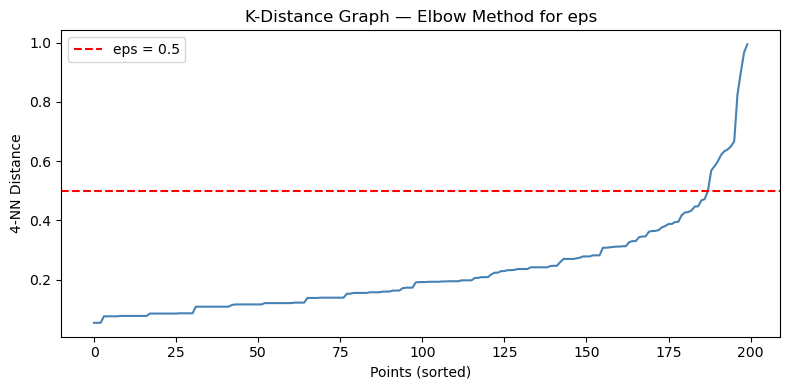

In [21]:
# min_samples is typically set to 2 * number_of_features
min_samples = 4

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(features_scaled)
distances, _ = nbrs.kneighbors(features_scaled)
k_distances = np.sort(distances[:, min_samples - 1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='steelblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps = 0.5')
plt.xlabel('Points (sorted)')
plt.ylabel(f'{min_samples}-NN Distance')
plt.title('K-Distance Graph — Elbow Method for eps')
plt.legend()
plt.tight_layout()
plt.show()

The curve rises gradually and then bends upward at a certain point. That bend is the elbow, and the distance at that inflection is a good eps value to use. From this graph, `eps = 0.5` sits right at that bend before distances start jumping, so that's what gets passed to the model.

## 5. Applying DBSCAN

In [22]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(features_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'Number of clusters found: {n_clusters}')
print(f'Number of noise points:   {n_noise}')
print(f'\nCluster label counts:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

Number of clusters found: 2
Number of noise points:   8

Cluster label counts:
-1      8
 0    157
 1     35
Name: count, dtype: int64


Each point gets assigned a cluster label starting from 0, or -1 if DBSCAN decides it doesn't belong to any dense region. Those -1 points are the noise points — the algorithm's way of flagging that this customer doesn't fit cleanly into any group. That distinction is something K-Means is not capable of making.

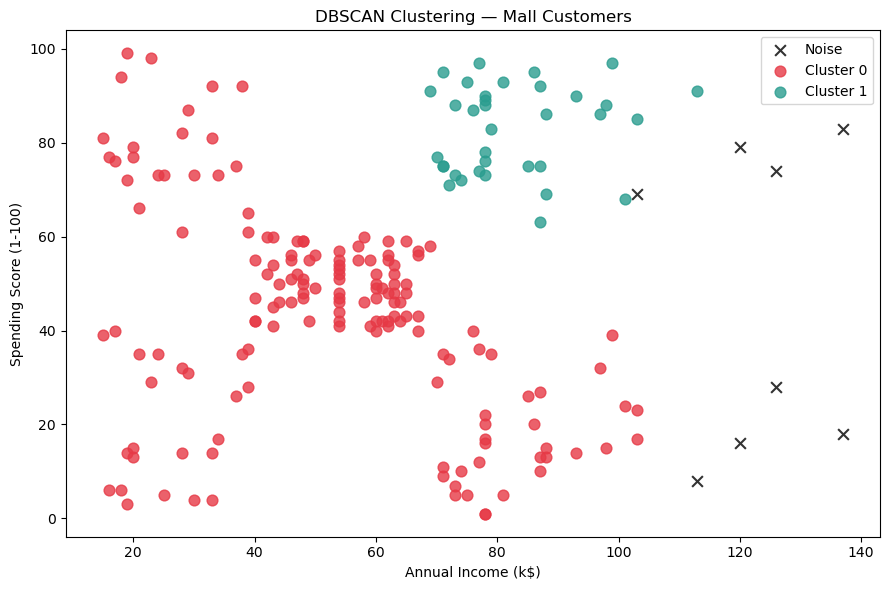

In [23]:
palette = {-1: 'black', 0: '#E63946', 1: '#2A9D8F', 2: '#E9C46A', 3: '#457B9D', 4: '#F4A261'}

plt.figure(figsize=(9, 6))
for label in sorted(df['DBSCAN_Cluster'].unique()):
    mask = df['DBSCAN_Cluster'] == label
    color = palette.get(label, 'grey')
    cluster_name = 'Noise' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=color, label=cluster_name, marker=marker, s=60, alpha=0.8
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering — Mall Customers')
plt.legend()
plt.tight_layout()
plt.show()

The scatter shows the clusters in the original income and spending space so the values stay readable. The X markers are the noise points — they sit in sparser areas where there aren't enough nearby customers around them to form a proper cluster.

## 6. Silhouette Score for DBSCAN

In [24]:
# Silhouette score only works on non-noise points
mask_non_noise = dbscan_labels != -1

if mask_non_noise.sum() > 1 and len(set(dbscan_labels[mask_non_noise])) > 1:
    sil_dbscan = silhouette_score(features_scaled[mask_non_noise], dbscan_labels[mask_non_noise])
    print(f'DBSCAN Silhouette Score (excluding noise): {sil_dbscan:.4f}')
else:
    print('Not enough clusters/points to compute silhouette score.')

DBSCAN Silhouette Score (excluding noise): 0.3876


The silhouette score runs from -1 to 1 and measures how well each point sits within its assigned cluster compared to the others. Noise points are excluded from the calculation since they have no cluster. A score above 0.5 generally means the clusters are reasonably distinct from one another, though the score here is lower because DBSCAN only found two broad groupings rather than tighter, more separated ones.

## 7. Applying K-Means for Comparison

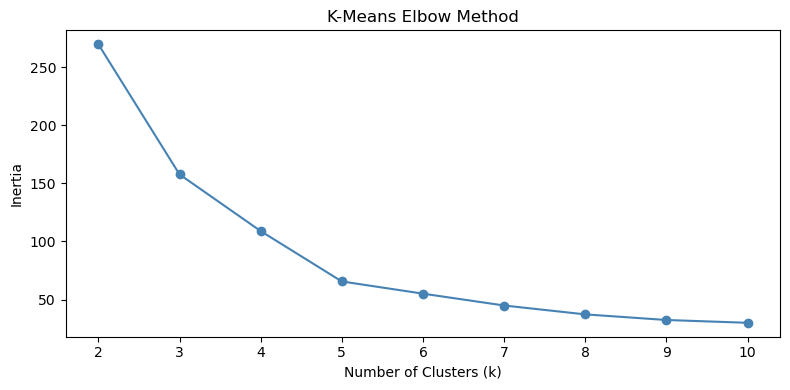

In [25]:
# Use the elbow method to pick the right k
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.tight_layout()
plt.show()

Inertia drops sharply from k=2 through to around k=5, then flattens out. The elbow sits at k=5 — adding more clusters beyond that point stops providing meaningful improvement. Five clusters also lines up with what the literature typically reports for this dataset.

K-Means Silhouette Score: 0.5547


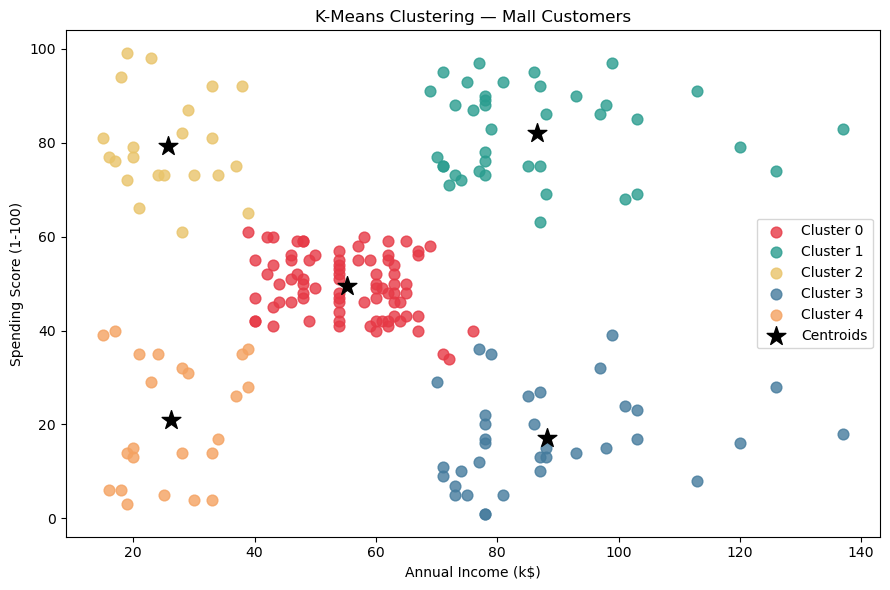

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(features_scaled)
df['KMeans_Cluster'] = kmeans_labels

sil_kmeans = silhouette_score(features_scaled, kmeans_labels)
print(f'K-Means Silhouette Score: {sil_kmeans:.4f}')

# Plot K-Means clusters
colors_km = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#F4A261']

plt.figure(figsize=(9, 6))
for label in range(5):
    mask = df['KMeans_Cluster'] == label
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors_km[label], label=f'Cluster {label}', s=60, alpha=0.8
    )

centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            c='black', marker='*', s=200, zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering — Mall Customers')
plt.legend()
plt.tight_layout()
plt.show()

K-Means with k=5 gives five clearly defined groups with centroids marked as black stars. Every single point gets assigned to one of the five clusters — there is no noise label. That means any genuinely atypical customer just gets pulled toward the nearest centroid, which can make the result look cleaner than the data actually is.

## 8. Side-by-Side Comparison

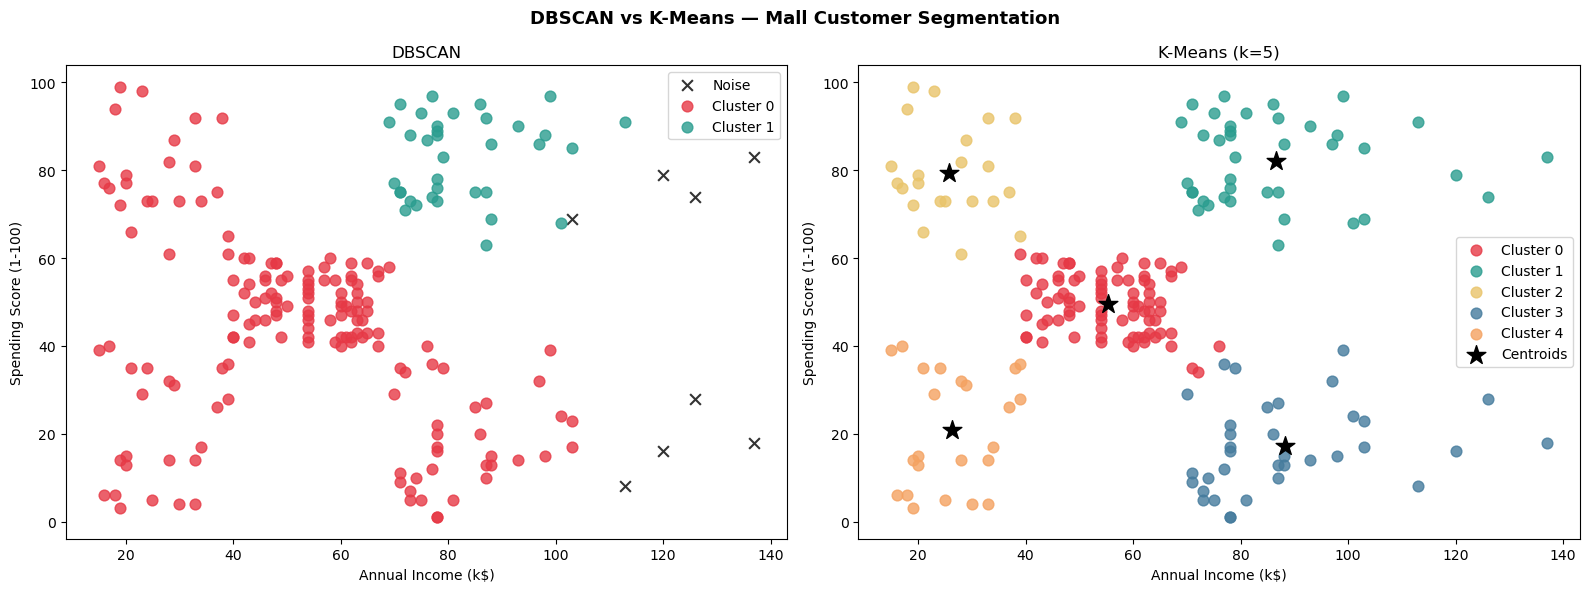

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
for label in sorted(df['DBSCAN_Cluster'].unique()):
    mask = df['DBSCAN_Cluster'] == label
    color = palette.get(label, 'grey')
    cluster_name = 'Noise' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    axes[0].scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=color, label=cluster_name, marker=marker, s=60, alpha=0.8
    )
axes[0].set_title('DBSCAN')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend()

# K-Means
for label in range(5):
    mask = df['KMeans_Cluster'] == label
    axes[1].scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors_km[label], label=f'Cluster {label}', s=60, alpha=0.8
    )
axes[1].scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                c='black', marker='*', s=200, zorder=5, label='Centroids')
axes[1].set_title('K-Means (k=5)')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend()

plt.suptitle('DBSCAN vs K-Means — Mall Customer Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Looking at both plots side by side, the general shape of the customer landscape is recognisably similar, but the key difference is the noise points on the DBSCAN side. K-Means spreads all 200 customers across five clusters and calls it done. DBSCAN keeps eight of them separate, acknowledging that they don't quite fit into any natural grouping.

## 9. Cluster Profiles

In [28]:
print('=== DBSCAN Cluster Profiles ===')
dbscan_profile = df.groupby('DBSCAN_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
dbscan_profile['Count'] = df.groupby('DBSCAN_Cluster')['CustomerID'].count()
print(dbscan_profile)

print('\n=== K-Means Cluster Profiles ===')
kmeans_profile = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
kmeans_profile['Count'] = df.groupby('KMeans_Cluster')['CustomerID'].count()
print(kmeans_profile)

=== DBSCAN Cluster Profiles ===
                 Age  Annual Income (k$)  Spending Score (1-100)  Count
DBSCAN_Cluster                                                         
-1              35.8               122.8                    46.9      8
 0              40.4                52.5                    43.1    157
 1              32.7                82.5                    82.8     35

=== K-Means Cluster Profiles ===
                 Age  Annual Income (k$)  Spending Score (1-100)  Count
KMeans_Cluster                                                         
0               42.7                55.3                    49.5     81
1               32.7                86.5                    82.1     39
2               25.3                25.7                    79.4     22
3               41.1                88.2                    17.1     35
4               45.2                26.3                    20.9     23


The averages per cluster are where the segmentation becomes actionable. Reading across age, income, and spending score for each group gives a clear picture of who sits in each cluster and how they behave, which is the starting point for any real marketing decision.

## 10. Algorithm Comparison Summary

In [29]:
comparison = pd.DataFrame({
    'Metric': ['Algorithm', 'Clusters Found', 'Noise Points', 'Requires k upfront', 'Silhouette Score', 'Handles Outliers'],
    'DBSCAN': ['Density-based', n_clusters, n_noise, 'No', f'{sil_dbscan:.4f}', 'Yes (labels as noise)'],
    'K-Means': ['Centroid-based', 5, 0, 'Yes', f'{sil_kmeans:.4f}', 'No (absorbed into clusters)']
})

comparison.set_index('Metric', inplace=True)
print(comparison.to_string())

                                   DBSCAN                      K-Means
Metric                                                                
Algorithm                   Density-based               Centroid-based
Clusters Found                          2                            5
Noise Points                            8                            0
Requires k upfront                     No                          Yes
Silhouette Score                   0.3876                       0.5547
Handles Outliers    Yes (labels as noise)  No (absorbed into clusters)


The table makes the trade-off between the two algorithms easy to read at a glance. DBSCAN found fewer clusters and surfaced some noise, while K-Means produced more distinct segments but forced every point in. The silhouette score is higher for K-Means here, which partly reflects the fact that DBSCAN is working with two broad clusters rather than five tighter ones, tighter clusters tend to score better.

---
## Findings and Business Interpretation

### What DBSCAN Found

DBSCAN found two clusters and flagged eight customers as noise. The noise points (label = -1) are customers whose income and spending combination sits far enough from any dense region that the algorithm refuses to place them in a group. Their average income is around $122k, which is the highest of any group, but their spending score sits at just 46.9 — so they earn well but they're not spending here. Whether that's a product fit issue or just sparse data in that part of the space is worth looking into.

Cluster 0 is by far the largest with 157 customers with moderate income around $52.5k and a spending score of 43.1. This is the broad middle of the customer base, people who earn a fair amount and spend at a fairly average rate.

Cluster 1 is smaller at 35 customers but arguably more interesting — average income of $82.5k and a spending score of 82.8. These are the high earners who actually spend, and at an average age of 32.7 they're also the youngest group. From a retail standpoint, this is the segment worth paying most attention to.

### What K-Means Found



K-Means with k=5 breaks the customer base down into five groups, giving a more detailed picture than DBSCAN's two:

| Cluster | Avg Income (k$) | Avg Spending Score | Avg Age | Count |
|---------|-----------------|--------------------|---------|-------|
| 0       | 55.3            | 49.5               | 43      | 81    |
| 1       | 86.5            | 82.1               | 33      | 39    |
| 2       | 25.7            | 79.4               | 25      | 22    |
| 3       | 88.2            | 17.1               | 41      | 35    |
| 4       | 26.3            | 20.9               | 45      | 23    |

Cluster 0 is the middle ground for average income, average spending, and the largest group at 81 customers.

Cluster 1 is high income and high spending. Young at an average of 33, earning well and spending freely. The most commercially valuable group.

Cluster 2 has low income but high spending. Probably younger shoppers who prioritise experiences over saving. Trend-driven promotions and instalment options would likely work well here.

Cluster 3 is high income but very low spending. They have the money but are not using it at this mall. Could be a product range issue, a brand perception issue, or just a lack of awareness.

Cluster 4 is low income and low spending. These customers shop out of necessity and will not respond to much beyond genuine value deals.

### DBSCAN vs K-Means

The two algorithms tell broadly the same story but at different levels of detail. K-Means produces a cleaner five-way split that maps onto recognisable customer types and scores a silhouette of 0.5547, compared to DBSCAN's 0.3876. The higher score reflects tighter, more separated clusters rather than either algorithm being fundamentally wrong.

DBSCAN's real contribution here is the noise detection. Those eight flagged customers are high earners with low spending — a pattern that doesn't sit cleanly in any of the five K-Means groups either, but K-Means absorbs them into Cluster 3 and moves on. DBSCAN at least makes the ambiguity visible.

For campaign targeting, K-Means is the more useful output because it gives five groups with clear, readable profiles. DBSCAN is better suited for auditing the data or finding customers who genuinely don't fit the standard segments and need a different approach.

### Practical Takeaway

Cluster 1: high income, high spending, younger age — is the group that drives the most value and deserves the most attention when it comes to retention, rewards, and personalisation. Cluster 3 is the biggest missed opportunity in the data: customers earning close to $90k a year but spending almost nothing. Understanding what's stopping that group from converting is probably the most useful question this analysis raises.